### PageRank

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [109]:
candidate_corr_thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]

In [119]:
residuals = pd.read_csv("../data/manipulated/residuals.csv", index_col=0)
equity_corr = pd.read_csv("../data/manipulated/residuals.csv", index_col=0).corr()

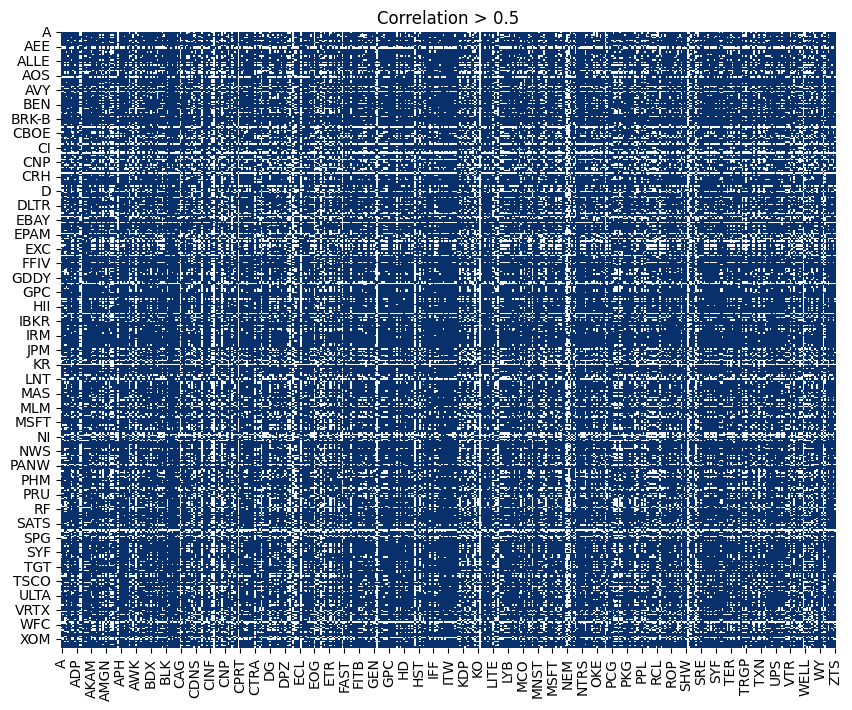

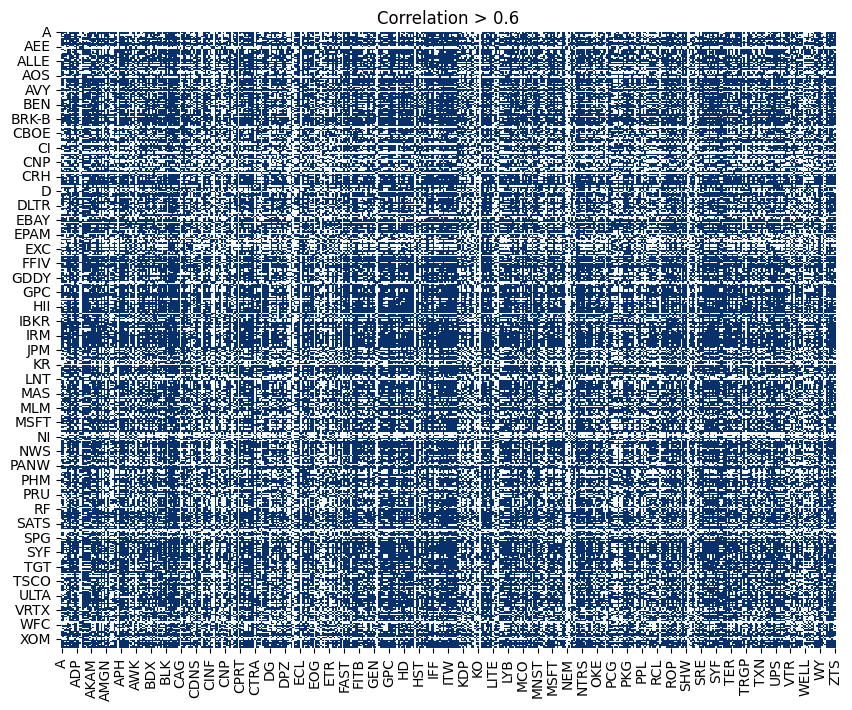

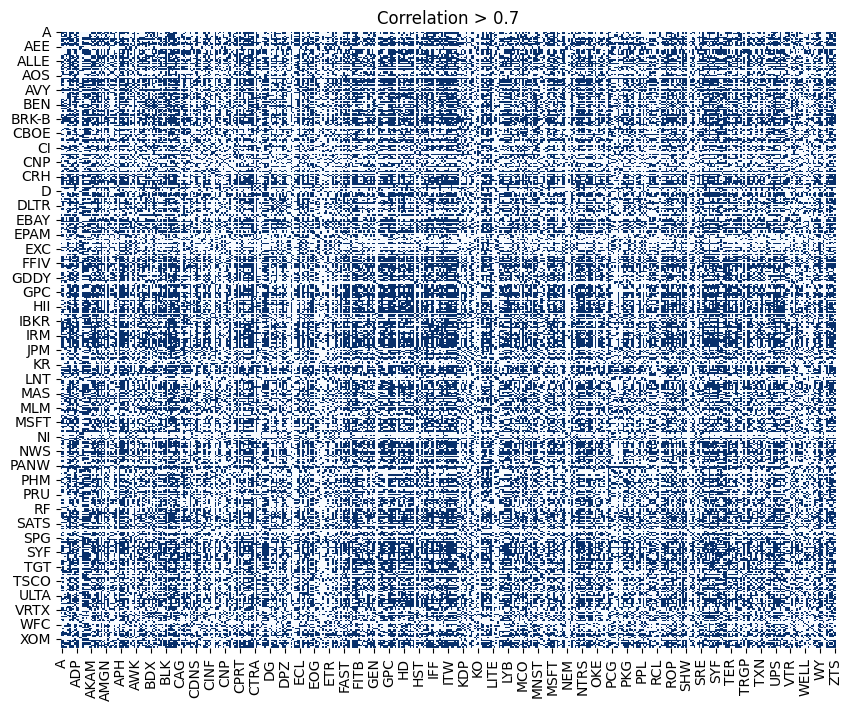

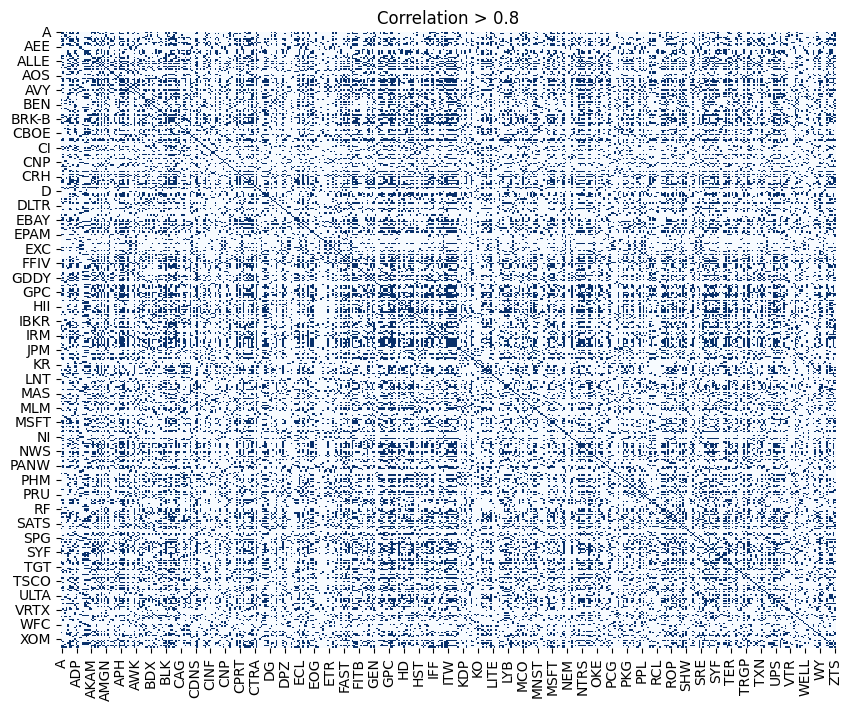

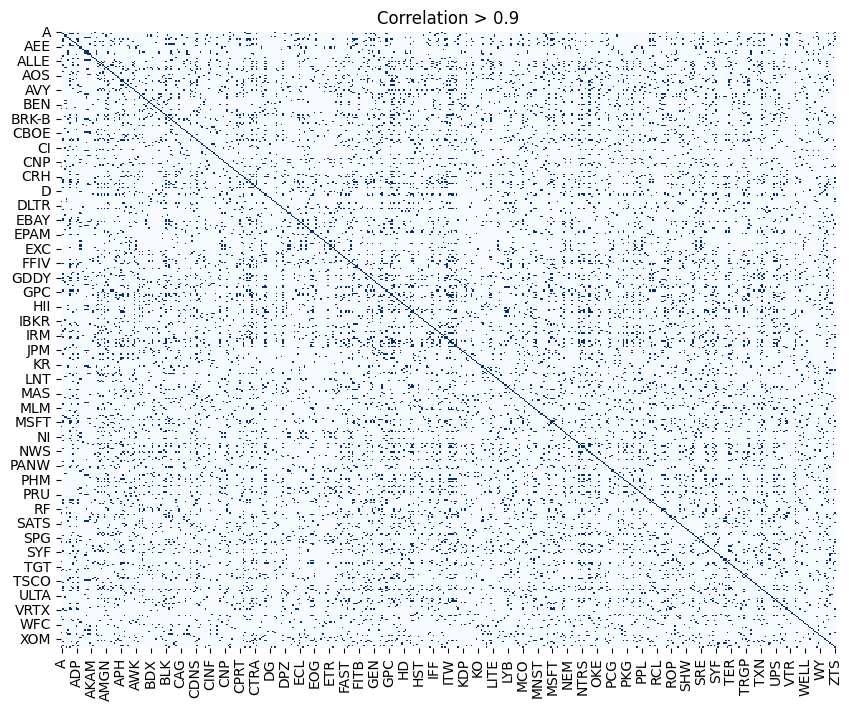

In [111]:
for candidate_threshold in candidate_corr_thresholds:
    plt.figure(figsize=(10, 8))
    sns.heatmap(equity_corr > candidate_threshold, cmap="Blues", cbar=False)
    plt.title(f"Correlation > {candidate_threshold}")
    plt.show()

Purely hueristically, I choose a threshold of 0.8, because this is the first value for which the diagonal line is distinct from the rest of the data on the heatmap. (WIP - will explain in more detail)

In [112]:
# config
CORR_THRESHOLD = 0.8
NUM_ASSETS = 25

In [113]:
def pagerank(mtx, beta=0.85, tol=1e-6, max_iter=100):
    """
    Compute PageRank scores.

    Parameters:
        mtx (pd.DataFrame or np.ndarray): adjacency matrix (0/1 or weights)
        beta (float): damping factor
        tol (float): convergence tolerance
        max_iter (int): max iterations

    Returns:
        np.ndarray: PageRank vector
    """
    # convert to numpy
    A = mtx.to_numpy() if hasattr(mtx, "to_numpy") else mtx
    n = A.shape[0]

    # row-normalize (handle dangling nodes)
    row_sums = A.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # avoid division by zero
    P = A / row_sums

    # initialize rank vector
    r = np.ones(n) / n

    # power iteration
    for _ in range(max_iter):
        r_new = beta * P.T @ r + (1 - beta) / n

        if np.linalg.norm(r_new - r, 1) < tol:
            break

        r = r_new

    return r

In [114]:
# construct weighted link matrix
weight_matrix = equity_corr.copy()
weight_matrix[equity_corr <= CORR_THRESHOLD] = 0
weight_matrix = weight_matrix ** 2  # emphasize stronger correlations
weight_matrix = weight_matrix.mask(np.eye(len(weight_matrix), dtype=bool), 0)

# run pagerank on weighted matrix
r = pagerank(weight_matrix)
pagerank_df = pd.DataFrame({
    "Asset": weight_matrix.index,
    "PageRank": r
}).sort_values("PageRank", ascending=False)

top_assets = pagerank_df.head(NUM_ASSETS)
print(top_assets)

    Asset  PageRank
118  CTSH  0.004359
82    CDW  0.004349
260   LIN  0.004148
78   CBRE  0.003970
211   HON  0.003969
200  GRMN  0.003958
415  TRMB  0.003915
63    BLK  0.003904
144   ECL  0.003859
115   CSX  0.003852
35    APD  0.003839
24   AMCR  0.003821
176  FFIV  0.003803
204   HAS  0.003785
431   UNP  0.003781
319   NWS  0.003731
110   CRH  0.003699
404   TEL  0.003694
213   HPQ  0.003686
313   NSC  0.003679
459    WY  0.003671
248   KKR  0.003642
185   FTV  0.003626
376  SBUX  0.003626
44    AVY  0.003603


In [115]:
r = pagerank(weight_matrix)
pagerank_df = pd.DataFrame({
    "Asset": weight_matrix.index,
    "PageRank": r
}).sort_values("PageRank", ascending=False)

top_assets = pagerank_df.head(NUM_ASSETS)
print(top_assets)

    Asset  PageRank
118  CTSH  0.004359
82    CDW  0.004349
260   LIN  0.004148
78   CBRE  0.003970
211   HON  0.003969
200  GRMN  0.003958
415  TRMB  0.003915
63    BLK  0.003904
144   ECL  0.003859
115   CSX  0.003852
35    APD  0.003839
24   AMCR  0.003821
176  FFIV  0.003803
204   HAS  0.003785
431   UNP  0.003781
319   NWS  0.003731
110   CRH  0.003699
404   TEL  0.003694
213   HPQ  0.003686
313   NSC  0.003679
459    WY  0.003671
248   KKR  0.003642
185   FTV  0.003626
376  SBUX  0.003626
44    AVY  0.003603


/tmp/ipykernel_22492/3860322374.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="PageRank", y="Asset", data=top_assets, palette="viridis")


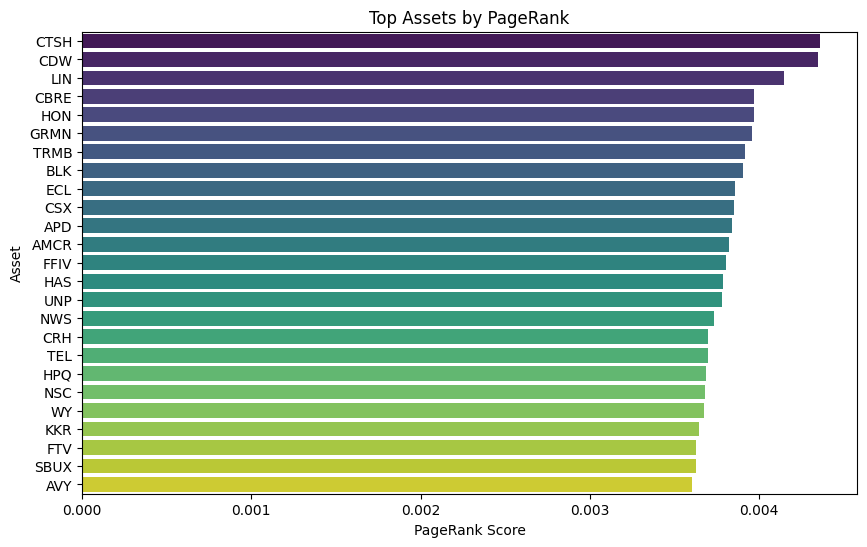

In [116]:
# make sorted bar graph of pagerank of top assets
plt.figure(figsize=(10, 6))
sns.barplot(x="PageRank", y="Asset", data=top_assets, palette="viridis")
plt.title("Top Assets by PageRank")
plt.xlabel("PageRank Score")
plt.ylabel("Asset")
plt.show()

In [122]:
filtered_residuals = residuals[top_assets["Asset"]]

filtered_residuals.to_csv("../data/manipulated/pr_filtered_residuals.csv", index=False)